In [55]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout, SpatialDropout1D, GRU
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

df = pd.read_csv('dataset_reviews.csv')
print("Jumlah data awal:", len(df))
df.head()

Jumlah data awal: 10500


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\atha\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,text,score
0,ko fitur dana instan nya belom timbul.padahal ...,5
1,sangat cocok untuk menyimpan uang,5
2,sekarang sering gangguan,3
3,👌👌,2
4,karena ingin mengirim sesama bank tidak membayar,5


In [56]:
import pandas as pd
import numpy as np
import re

def label_sentiment(score):
    if score <= 2:
        return 'negatif'
    elif score == 3:
        return 'netral'
    else:
        return 'positif'

df['sentiment'] = df['score'].apply(label_sentiment)

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()                                    
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)     
    text = re.sub(r'[^\w\s]', '', text)                     
    text = re.sub(r'\d+', '', text)                         
    tokens = text.split()
    tokens = [w for w in tokens if len(w) > 1] 
    return " ".join(tokens)

df['clean_text'] = df['text'].apply(clean_text)
df = df.dropna(subset=['clean_text']).drop_duplicates(subset=['clean_text'])
df = df[df['clean_text'].str.strip() != '']

print("Jumlah data saat ini (Pastikan >10.000):", len(df))
print(df['sentiment'].value_counts())

Jumlah data saat ini (Pastikan >10.000): 6510
sentiment
positif    3960
negatif    2176
netral      374
Name: count, dtype: int64


In [57]:
!pip install imbalanced-learn

In [58]:
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.over_sampling import SMOTE
from tensorflow.keras.utils import to_categorical

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=3)
X_tfidf = vectorizer.fit_transform(df['clean_text']).toarray()

label_map = {'negatif': 0, 'netral': 1, 'positif': 2}
Y_labels = df['sentiment'].map(label_map).values

print("Distribusi kelas SEBELUM SMOTE:\n", np.bincount(Y_labels))

smote = SMOTE(random_state=42)
X_smote, Y_smote = smote.fit_resample(X_tfidf, Y_labels)

print("\nDistribusi kelas SETELAH SMOTE (Sekarang seimbang!):\n", np.bincount(Y_smote))

Y_smote_cat = to_categorical(Y_smote)

Distribusi kelas SEBELUM SMOTE:
 [2176  374 3960]

Distribusi kelas SETELAH SMOTE (Sekarang seimbang!):
 [3960 3960 3960]


In [59]:
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

callbacks_es = [EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)]

# ===================================================================
# SKEMA 1: Deep Learning + SMOTE (Split 80/20)
# ===================================================================
X_train1, X_test1, Y_train1, Y_test1 = train_test_split(X_smote, Y_smote_cat, test_size=0.2, random_state=42)

model1 = Sequential([
    # Input dibuat otomatis mengikuti jumlah fitur/kata dari X_train1
    Input(shape=(X_train1.shape[1],)), 
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')
])
model1.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

print("=== Training Skema 1 (Deep Learning + SMOTE) ===")
history1 = model1.fit(X_train1, Y_train1, epochs=15, batch_size=32, 
                      validation_data=(X_test1, Y_test1), callbacks=callbacks_es, verbose=1)

acc1 = model1.evaluate(X_test1, Y_test1, verbose=0)[1]
print(f"-> Akurasi Testing Skema 1 (DL): {acc1 * 100:.2f}%\n")


# ===================================================================
# SKEMA 2: SVM + SMOTE (Split 80/20)
# ===================================================================
X_train2, X_test2, y_train2, y_test2 = train_test_split(X_smote, Y_smote, test_size=0.2, random_state=123)

print("=== Training Skema 2 (SVM + SMOTE) ===")
model2 = LinearSVC(C=1.0, max_iter=2000, random_state=42)
model2.fit(X_train2, y_train2)

y_pred2 = model2.predict(X_test2)
acc2 = accuracy_score(y_test2, y_pred2)
print(f"-> Akurasi Testing Skema 2 (SVM): {acc2 * 100:.2f}%\n")


# ===================================================================
# SKEMA 3: Naive Bayes + SMOTE (Split 70/30)
# ===================================================================
X_train3, X_test3, y_train3, y_test3 = train_test_split(X_smote, Y_smote, test_size=0.3, random_state=999)

print("=== Training Skema 3 (Naive Bayes + SMOTE) ===")
model3 = MultinomialNB(alpha=0.1)
model3.fit(X_train3, y_train3)

y_pred3 = model3.predict(X_test3)
acc3 = accuracy_score(y_test3, y_pred3)
print(f"-> Akurasi Testing Skema 3 (Naive Bayes): {acc3 * 100:.2f}%\n")

=== Training Skema 1 (Deep Learning + SMOTE) ===
Epoch 1/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6520 - loss: 0.8232 - val_accuracy: 0.7862 - val_loss: 0.5437
Epoch 2/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8591 - loss: 0.4017 - val_accuracy: 0.8540 - val_loss: 0.4018
Epoch 3/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9164 - loss: 0.2418 - val_accuracy: 0.8674 - val_loss: 0.4015
Epoch 4/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9413 - loss: 0.1718 - val_accuracy: 0.8666 - val_loss: 0.3925
Epoch 5/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9518 - loss: 0.1328 - val_accuracy: 0.8624 - val_loss: 0.4597
Epoch 6/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9617 - loss: 0.1038 - val_accuracy: 0.8935 - val_loss: 0.4389
Epoch 7/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9624 - loss: 0.0962 - val_accuracy: 0.8859 - val_loss: 0.4741
Epoch 8/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - a

75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

--- Classification Report (Model Terbaik) ---
              precision    recall  f1-score   support

     negatif       0.85      0.90      0.87       779
      netral       0.94      0.97      0.96       807
     positif       0.90      0.81      0.85       790

    accuracy                           0.89      2376
   macro avg       0.89      0.89      0.89      2376
weighted avg       0.89      0.89      0.89      2376



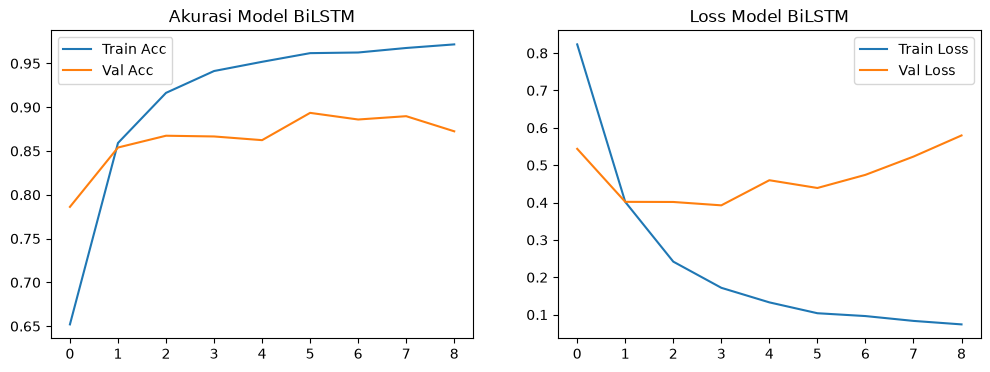

In [60]:
y_pred = model1.predict(X_test1)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(Y_test1, axis=1)

labels_map = ['negatif', 'netral', 'positif']

print("\n--- Classification Report (Model Terbaik) ---")
print(classification_report(y_true_classes, y_pred_classes, target_names=labels_map))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history1.history['accuracy'], label='Train Acc')
plt.plot(history1.history['val_accuracy'], label='Val Acc')
plt.title('Akurasi Model BiLSTM')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history1.history['loss'], label='Train Loss')
plt.plot(history1.history['val_loss'], label='Val Loss')
plt.title('Loss Model BiLSTM')
plt.legend()
plt.show()

In [61]:
def predict_sentiment_text(text_input, model, vectorizer_model):
    cleaned = clean_text(text_input)
    
    features = vectorizer_model.transform([cleaned]).toarray()
    
    pred = model.predict(features, verbose=0)
    class_idx = np.argmax(pred, axis=1)[0]
    confidence = pred[0][class_idx] * 100
    
    classes = ['Negatif', 'Netral', 'Positif']
    return classes[class_idx], confidence

sample_reviews = [
    "Aplikasi ini sangat bagus dan cepat saat transaksi! Transaksi sukses tanpa hambatan.",
    "Fiturnya lumayan, tapi kadang loading-nya sedikit lama saat jam sibuk.",
    "Sangat mengecewakan! Saldo saya berkurang tapi transaksi gagal, mana aplikasinya lambat banget!"
]

print("=== HASIL PENGUJIAN INFERENSI MODUL SENTIMEN ===")
print("-" * 75)
for text in sample_reviews:
    label, conf = predict_sentiment_text(text, model1, vectorizer)
    print(f"Teks Input  : \"{text}\"")
    print(f"Hasil Kelas : [{label.upper()}] (Tingkat Keyakinan: {conf:.2f}%)")
    print("-" * 75)

=== HASIL PENGUJIAN INFERENSI MODUL SENTIMEN ===
---------------------------------------------------------------------------
Teks Input  : "Aplikasi ini sangat bagus dan cepat saat transaksi! Transaksi sukses tanpa hambatan."
Hasil Kelas : [POSITIF] (Tingkat Keyakinan: 100.00%)
---------------------------------------------------------------------------
Teks Input  : "Fiturnya lumayan, tapi kadang loading-nya sedikit lama saat jam sibuk."
Hasil Kelas : [POSITIF] (Tingkat Keyakinan: 97.67%)
---------------------------------------------------------------------------
Teks Input  : "Sangat mengecewakan! Saldo saya berkurang tapi transaksi gagal, mana aplikasinya lambat banget!"
Hasil Kelas : [NEGATIF] (Tingkat Keyakinan: 99.99%)
---------------------------------------------------------------------------
